# Limpieza de `.mdx` — antes y después

Este notebook es el test de `src/ingest/preprocess_mdx.py`, el script que convierte
la documentación MDX de MLflow (`data/raw/`) en documentos limpios listos para
trocear y vectorizar (`data/processed/`).

Está pensado para **ver** lo que hace la limpieza, no solo para comprobar que pasa:

1. El fragmento sin procesar
2. El resultado
3. Los dos lado a lado
4. El *diff*: qué se ha quitado exactamente
5. **Paso a paso**: el texto después de cada etapa del pipeline
6. Las comprobaciones (esta es la parte de test propiamente dicha)
7. La misma comparación sobre un documento real del corpus
8. El corpus entero: distribución de longitudes

Ejecuta las celdas en orden (*Run All*). La celda 6 falla con `AssertionError` si
alguna comprobación no pasa.

## 0. Preparación

In [1]:
import difflib
import html
import json
import re
import sys
from pathlib import Path


def raiz_del_proyecto():
    # Funciona tanto si el notebook se abre desde tests/ como desde la raiz.
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "src" / "ingest" / "preprocess_mdx.py").exists():
            return base
    raise RuntimeError("no encuentro la raiz del proyecto desde " + str(Path.cwd()))


RAIZ = raiz_del_proyecto()
FIXTURES = RAIZ / "tests" / "fixtures"
sys.path.insert(0, str(RAIZ / "src" / "ingest"))

import preprocess_mdx as P
from IPython.display import HTML, display

print("raiz    :", RAIZ)
print("modulo  :", P.__file__)
print("fixtures:", FIXTURES)

raiz    : c:\Users\Ainhoa\Documents\PROIEKTUAK\RAG
modulo  : c:\Users\Ainhoa\Documents\PROIEKTUAK\RAG\src\ingest\preprocess_mdx.py
fixtures: c:\Users\Ainhoa\Documents\PROIEKTUAK\RAG\tests\fixtures


In [2]:
# Utilidades de presentacion. Los colores son semitransparentes y el texto hereda
# el color del tema, asi que se ven bien en Jupyter claro y oscuro.
ESTILO = '''
<style>
.cmp { display: flex; gap: 12px; align-items: stretch; }
.cmp > div { flex: 1 1 0; min-width: 0; }
.panel { border: 1px solid rgba(128,128,128,.45); border-radius: 6px;
         overflow: auto; max-height: 560px; margin-bottom: 8px; }
.panel h4 { margin: 0; padding: 6px 10px; border-bottom: 1px solid rgba(128,128,128,.45);
            background: rgba(128,128,128,.12); font-family: system-ui, sans-serif;
            font-size: 11px; font-weight: 600; letter-spacing: .05em; text-transform: uppercase; }
.panel pre { margin: 0; padding: 10px; white-space: pre; color: inherit;
             font-family: ui-monospace, Consolas, monospace; font-size: 12px; line-height: 1.5; }
.panel .add { background: rgba(60,180,90,.22); display: block; }
.panel .del { background: rgba(220,70,70,.22); display: block; }
.panel .hdr { background: rgba(128,128,128,.20); display: block; opacity: .8; }
</style>
'''


def visible(texto):
    # Entre etapas, el codigo viaja escondido tras un marcador invisible: aqui se
    # sustituye por algo que se pueda leer.
    texto = P.CODE_MARK_RE.sub(lambda m: "[bloque de codigo " + m.group(1) + "]", texto)
    return re.sub(P.INLINE_MARK + r"(\d+)" + P.INLINE_MARK,
                  lambda m: "[cod " + m.group(1) + "]", texto)


def _panel(titulo, cuerpo_html):
    return ('<div class="panel"><h4>' + html.escape(titulo) + '</h4><pre>'
            + cuerpo_html + '</pre></div>')


def mostrar(titulo, texto):
    display(HTML(ESTILO + _panel(titulo, html.escape(texto))))


def comparar(titulo_a, texto_a, titulo_b, texto_b):
    izquierda = _panel(titulo_a, html.escape(texto_a))
    derecha = _panel(titulo_b, html.escape(texto_b))
    display(HTML(ESTILO + '<div class="cmp">' + izquierda + derecha + '</div>'))


def _clase(linea, indice):
    # Las dos primeras lineas son la cabecera del diff; a partir de ahi, una
    # linea que empiece por "---" es una linea borrada de verdad (por ejemplo
    # el delimitador del frontmatter), no una cabecera.
    if indice < 2 or linea.startswith("@@"):
        return "hdr"
    if linea.startswith("+"):
        return "add"
    if linea.startswith("-"):
        return "del"
    return ""


def diferencias(texto_a, texto_b, titulo="diff", contexto=2):
    lineas = list(difflib.unified_diff(texto_a.split("\n"), texto_b.split("\n"),
                                       fromfile="antes", tofile="despues",
                                       lineterm="", n=contexto))
    if not lineas:
        display(HTML(ESTILO + _panel(titulo, "(sin cambios)")))
        return
    cuerpo = "\n".join('<span class="' + _clase(l, i) + '">' + (html.escape(l) or "&nbsp;") + '</span>'
                       for i, l in enumerate(lineas))
    display(HTML(ESTILO + _panel(titulo, cuerpo)))


print("listo")

listo


## 1. El fragmento sin procesar

`tests/fixtures/sample_raw.mdx` no es un archivo real del corpus: es un fragmento
construido a propósito que reúne **todos** los patrones que aparecen en las docs de
MLflow y que dan problemas. De arriba abajo:

- frontmatter YAML e `import` de componentes React;
- un comentario MDX `{/* ... */}`;
- una sección (`Why MLflow + Keras?`) cuyo único contenido es un componente visual;
- un aviso `:::warning` de Docusaurus;
- `<APILink>` en sus dos formas (autocerrado y con hijos);
- `<TabsWrapper>/<Tabs>/<TabItem>/<div>` con el contenido sangrado 6 espacios;
- un bloque `bash` con líneas `export MLFLOW_TRACKING_URI=...` **dentro del código**;
- una tabla en HTML crudo;
- una rejilla de tarjetas con un apóstrofo dentro de una prop JSX (`your LLM's outputs`).

In [3]:
CRUDO = (FIXTURES / "sample_raw.mdx").read_text(encoding="utf-8")
mostrar("sample_raw.mdx  —  " + str(len(CRUDO)) + " caracteres", CRUDO)

## 2. El resultado

`clean_mdx()` devuelve cuatro cosas: el texto limpio, el frontmatter parseado, el
número de bloques de código y los encabezados.

In [4]:
LIMPIO, FRONT, N_BLOQUES, ENCABEZADOS = P.clean_mdx(CRUDO)

mostrar("resultado  —  " + str(len(LIMPIO)) + " caracteres", LIMPIO)

print("frontmatter:")
print(json.dumps(FRONT, ensure_ascii=False, indent=2))
print()
print("encabezados:")
for h in ENCABEZADOS:
    print("  " + "#" * h["level"] + " " + h["text"])
print()
print("bloques de codigo:", N_BLOQUES)
print("reduccion: {} -> {} caracteres ({:.0f}% menos)".format(
    len(CRUDO), len(LIMPIO), 100 * (1 - len(LIMPIO) / len(CRUDO))))

frontmatter:
{
  "title": "MLflow Keras 3.0 Integration",
  "description": "Log, track, and deploy Keras 3.0 models with MLflow.",
  "sidebar_position": 2,
  "sidebar_label": "Keras",
  "keywords": [
    "keras",
    "autologging",
    "tracking"
  ]
}

encabezados:
  # MLflow Keras 3.0 Integration
  ## Introduction
  ## Autologging
  #### Enable autologging
  ### 3. Check the results
  ## Supported output types

bloques de codigo: 2
reduccion: 2384 -> 907 caracteres (62% menos)


## 3. Los dos lado a lado

Los paneles tienen scroll propio. Fíjate en que el bloque de código sale intacto y
en que el contenido que estaba dentro de `<TabItem><div>` ha perdido la sangría de
6 espacios: si no, Markdown lo leería como un bloque de código indentado.

In [5]:
comparar("antes  (mdx)", CRUDO, "despues  (md)", LIMPIO)

## 4. El *diff*

En rojo lo que desaparece, en verde lo que se queda o aparece nuevo.

In [6]:
diferencias(CRUDO, LIMPIO, titulo="sample_raw.mdx  ->  resultado", contexto=1)

## 5. Paso a paso

Aquí es donde se ve *cómo* hace los cambios. `clean_mdx()` encadena estas etapas, y
el orden importa: **lo primero es esconder el código**. En este fragmento hay
`export MLFLOW_TRACKING_URI=...` (bash) e `import mlflow` (Python) dentro de bloques
de ejemplo; si se limpiasen las sentencias `import`/`export` antes de esconderlos, se
los llevaría por delante.

Mientras el código está escondido aparece como `[bloque de codigo N]`.

In [7]:
etapas = []


def registrar(nombre, texto):
    etapas.append((nombre, texto))


fuente = CRUDO.replace("\r\n", "\n")
raw_front, cuerpo = P.split_frontmatter(fuente)
registrar("0. frontmatter aparte", cuerpo)

boveda = P.CodeVault()
cuerpo = boveda.hide_fenced(cuerpo)
registrar("1. bloques de codigo escondidos", cuerpo)

cuerpo = boveda.hide_inline(cuerpo)
registrar("2. codigo en linea escondido", cuerpo)

cuerpo = P.MDX_COMMENT_RE.sub("", cuerpo)
cuerpo = P.HTML_COMMENT_RE.sub("", cuerpo)
registrar("3. sin comentarios", cuerpo)

cuerpo = P.ESM_IMPORT_RE.sub("", cuerpo)
cuerpo = P.ESM_EXPORT_RE.sub("", cuerpo)
registrar("4. sin import/export de ESM", cuerpo)

cuerpo = P.convert_html_tables(cuerpo)
registrar("5. tablas HTML a Markdown", cuerpo)

cuerpo = P.JsxRenderer(cuerpo).render()
registrar("6. JSX resuelto (descartar / desenvolver)", cuerpo)

cuerpo = P.normalize_admonitions(cuerpo)
registrar("7. avisos ::: normalizados", cuerpo)

cuerpo = P.tidy(cuerpo)
registrar("8. limpieza final", cuerpo)

cuerpo = boveda.restore(cuerpo)
registrar("9. codigo restaurado", cuerpo)

import pandas as pd

resumen = pd.DataFrame({
    "etapa": [n for n, _ in etapas],
    "caracteres": [len(t) for _, t in etapas],
    "lineas": [t.count("\n") + 1 for _, t in etapas],
})
resumen["cambio"] = resumen["caracteres"].diff().fillna(0).astype(int)
resumen

,etapa,caracteres,lineas,cambio
0,0. frontmatter aparte,2192,106,0
1,1. bloques de codigo escondidos,1989,98,-203
2,2. codigo en linea escondido,1976,98,-13
3,3. sin comentarios,1924,98,-52
4,4. sin import/export de ESM,1698,98,-226
5,5. tablas HTML a Markdown,1527,88,-171
6,6. JSX resuelto (descartar / desenvolver),792,80,-735
7,7. avisos ::: normalizados,790,80,-2
8,8. limpieza final,714,39,-76
9,9. codigo restaurado,906,47,192


Y el *diff* de cada etapa contra la anterior:

In [8]:
for (nombre_a, texto_a), (nombre_b, texto_b) in zip(etapas, etapas[1:]):
    diferencias(visible(texto_a), visible(texto_b),
                titulo=nombre_a + "   ->   " + nombre_b, contexto=1)

Si quieres mirar una etapa concreta entera en vez del *diff*, cambia el índice:

In [9]:
ETAPA = 6  # 0..9, segun la tabla de arriba
nombre, texto = etapas[ETAPA]
mostrar(nombre, visible(texto))

## 6. Comprobaciones

Esta es la parte de test. Cada línea fija una decisión del script: si alguien cambia
la limpieza y rompe una, esta celda falla.

In [10]:
ESPERADO = (FIXTURES / "sample_clean.md").read_text(encoding="utf-8")

COMPROBACIONES = [
    # --- el resultado completo, contra la salida ya revisada a mano ---
    ("el resultado coincide con tests/fixtures/sample_clean.md", LIMPIO == ESPERADO),

    # --- lo que se elimina ---
    ("elimina los import de ESM",
     "@site/src/components" not in LIMPIO and "lucide-react" not in LIMPIO),
    ("elimina los comentarios MDX",
     "{/*" not in LIMPIO and "no debe llegar al corpus" not in LIMPIO),
    ("elimina los componentes visuales con sus hijos",
     "TileCard" not in LIMPIO and "FeatureHighlights" not in LIMPIO
     and "Version and manage Keras models" not in LIMPIO),
    ("elimina las secciones que se quedan vacias",
     "Why MLflow + Keras?" not in LIMPIO and "Learn More" not in LIMPIO),
    ("un apostrofo en una prop JSX no vuelca el componente",
     "LLM's outputs" not in LIMPIO),
    ("no queda ninguna etiqueta suelta", "<" not in LIMPIO),
    ("el frontmatter no aparece en el texto", "sidebar_position" not in LIMPIO),

    # --- lo que se preserva ---
    ("preserva los bloques de codigo con su lenguaje",
     "```python" in LIMPIO and "```bash" in LIMPIO),
    ("NO toca los import/export que estan dentro del codigo",
     'export MLFLOW_TRACKING_URI="http://localhost:5000"' in LIMPIO and "import mlflow" in LIMPIO),
    ("preserva la jerarquia de encabezados",
     (1, "MLflow Keras 3.0 Integration") in [(h["level"], h["text"]) for h in ENCABEZADOS]
     and (2, "Autologging") in [(h["level"], h["text"]) for h in ENCABEZADOS]),
    ("los comentarios del codigo no cuentan como encabezados",
     [h["text"] for h in P.clean_mdx("# Titulo\n\n```python\n# comentario\nx = 1\n```\n")[3]] == ["Titulo"]),
    ("convierte las tablas HTML a Markdown",
     "| Pipeline Type | Output Type |" in LIMPIO
     and "| Text Classification | pd.DataFrame (dtypes: {'label': str}) |" in LIMPIO),
    ("desindenta el contenido de los contenedores JSX",
     all(not l.startswith("    ") for l in LIMPIO.split("\n")
         if l.strip().startswith(("#", "-", "**")))),
    ("conserva la etiqueta de cada pestaña",
     "**Python**" in LIMPIO and "**Shell**" in LIMPIO),
    ("resuelve los <APILink> a texto",
     "`mlflow.tensorflow.autolog`" in LIMPIO and "`MlflowCallback`" in LIMPIO),
    ("convierte los avisos ::: de Docusaurus",
     ":::" not in LIMPIO and "**Warning**" in LIMPIO),

    # --- metadatos ---
    ("extrae el frontmatter como metadatos",
     FRONT["title"] == "MLflow Keras 3.0 Integration"
     and FRONT["sidebar_label"] == "Keras"
     and FRONT["keywords"] == ["keras", "autologging", "tracking"]),
    ("funciona con documentos sin frontmatter",
     P.clean_mdx("## Prerequisites\n\nInstall MLflow first.\n")[1] == {}),
]

filas = "".join(
    '<tr><td style="padding:3px 10px;font-size:15px">' + ("&#9989;" if ok else "&#10060;")
    + '</td><td style="padding:3px 10px;font-family:system-ui,sans-serif;font-size:13px">'
    + html.escape(nombre) + '</td></tr>'
    for nombre, ok in COMPROBACIONES)
display(HTML('<table style="border-collapse:collapse">' + filas + '</table>'))

fallos = [nombre for nombre, ok in COMPROBACIONES if not ok]
print("{}/{} comprobaciones correctas".format(len(COMPROBACIONES) - len(fallos), len(COMPROBACIONES)))
assert not fallos, "comprobaciones fallidas: " + str(fallos)

✅,el resultado coincide con tests/fixtures/sample_clean.md
✅,elimina los import de ESM
✅,elimina los comentarios MDX
✅,elimina los componentes visuales con sus hijos
✅,elimina las secciones que se quedan vacias
✅,un apostrofo en una prop JSX no vuelca el componente
✅,no queda ninguna etiqueta suelta
✅,el frontmatter no aparece en el texto
✅,preserva los bloques de codigo con su lenguaje
✅,NO toca los import/export que estan dentro del codigo
✅,preserva la jerarquia de encabezados


19/19 comprobaciones correctas


Si has cambiado la limpieza a mejor y solo falla la primera comprobación, regenera
el fichero de referencia con la celda siguiente y vuelve a mirar el *diff* del punto
4 para confirmar que el cambio es el que querías.

In [11]:
# Descomenta para regenerar tests/fixtures/sample_clean.md
# (FIXTURES / "sample_clean.md").write_text(LIMPIO, encoding="utf-8", newline="\n")

## 7. Sobre un documento real

Lo mismo, pero con un archivo del corpus. Cambia `DOC` por cualquier ruta de
`data/raw/` y vuelve a ejecutar.

In [12]:
DOC = "mlflow/docs/docs/genai/tracing/integrations/listing/open-webui.mdx"
# Para coger uno al azar:
# import random
# DOC = random.choice([p.relative_to(RAIZ / "data" / "raw").as_posix()
#                      for p in (RAIZ / "data" / "raw").rglob("*.mdx")])

ruta = RAIZ / "data" / "raw" / DOC
crudo_real = ruta.read_text(encoding="utf-8", errors="replace")
limpio_real, front_real, bloques_real, enc_real = P.clean_mdx(crudo_real)

comparar(ruta.name + "  (crudo, " + str(len(crudo_real)) + " car.)", crudo_real,
         "limpio  (" + str(len(limpio_real)) + " car.)", limpio_real)

print("titulo     :", front_real.get("title", "(sin frontmatter)"))
print("keywords   :", front_real.get("keywords", []))
print("bloques    :", bloques_real)
print("encabezados:", len(enc_real))

titulo     : Tracing Open WebUI
keywords   : ['open-webui', 'tracing', 'mlflow', 'filter pipeline', 'chat', 'observability', 'no-code']
bloques    : 3
encabezados: 11


In [13]:
diferencias(crudo_real, limpio_real, titulo=DOC, contexto=1)

## 8. El corpus entero

Lo que pide la fase 1 del plan: contar cosas antes de seguir. Necesita
`data/processed/documents.jsonl`, que se genera con:

```bash
python src/ingest/preprocess_mdx.py
```

In [14]:
import pandas as pd

ruta_jsonl = RAIZ / "data" / "processed" / "documents.jsonl"
if not ruta_jsonl.exists():
    print("Falta " + str(ruta_jsonl) + "\nEjecuta antes: python src/ingest/preprocess_mdx.py")
    docs = None
else:
    docs = pd.read_json(ruta_jsonl, lines=True)
    print("documentos          :", len(docs))
    print("caracteres totales  :", int(docs["n_chars"].sum()))
    print("bloques de codigo   :", int(docs["n_code_blocks"].sum()))
    print("triviales (<500)    :", int((docs["n_chars"] < 500).sum()))
    print("grandes (>20.000)   :", int((docs["n_chars"] > 20000).sum()))
    display(docs["n_chars"].describe().to_frame().T)

documentos          : 323
caracteres totales  : 2614730
bloques de codigo   : 2142
triviales (<500)    : 21
grandes (>20.000)   : 22


,count,mean,std,min,25%,50%,75%,max
n_chars,323.0,8095.139319,8016.516524,142.0,3304.5,5780.0,9959.5,71462.0


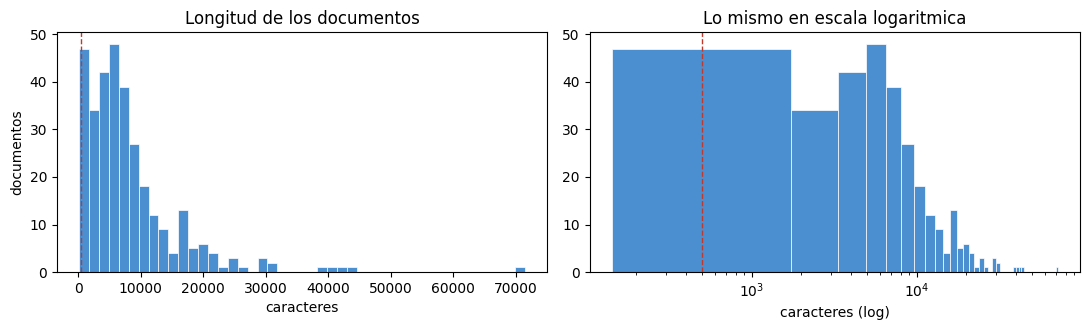

In [15]:
import matplotlib.pyplot as plt

if docs is not None:
    fig, ejes = plt.subplots(1, 2, figsize=(11, 3.4))

    ejes[0].hist(docs["n_chars"], bins=45, color="#4c8fd1", edgecolor="white", linewidth=.5)
    ejes[0].axvline(500, color="#c0392b", linestyle="--", linewidth=1)
    ejes[0].set_title("Longitud de los documentos")
    ejes[0].set_xlabel("caracteres")
    ejes[0].set_ylabel("documentos")

    ejes[1].hist(docs["n_chars"], bins=45, color="#4c8fd1", edgecolor="white", linewidth=.5)
    ejes[1].set_xscale("log")
    ejes[1].axvline(500, color="#c0392b", linestyle="--", linewidth=1)
    ejes[1].set_title("Lo mismo en escala logaritmica")
    ejes[1].set_xlabel("caracteres (log)")

    fig.tight_layout()
    plt.show()

In [16]:
if docs is not None:
    display(docs.nlargest(10, "n_chars")[["doc_id", "n_chars", "n_code_blocks"]]
            .reset_index(drop=True))
    display(docs.nsmallest(10, "n_chars")[["doc_id", "n_chars", "n_code_blocks"]]
            .reset_index(drop=True))

,doc_id,n_chars,n_code_blocks
0,mlflow/docs/docs/classic-ml/model/index,71462,42
1,mlflow/docs/docs/classic-ml/model/signatures/i...,43662,71
2,mlflow/docs/docs/genai/flavors/chat-model-guid...,42487,11
3,mlflow/docs/docs/classic-ml/model-registry/wor...,40786,36
4,mlflow/docs/docs/classic-ml/model/dependencies...,38621,45
5,mlflow/docs/docs/genai/flavors/chat-model-intr...,30359,21
6,mlflow/docs/docs/classic-ml/deep-learning/tran...,30307,12
7,mlflow/docs/docs/genai/tracing/app-instrumenta...,30052,28
8,mlflow/docs/docs/genai/prompt-registry/optimiz...,29428,16
9,mlflow/docs/docs/self-hosting/architecture/tra...,28795,28


,doc_id,n_chars,n_code_blocks
0,mlflow/docs/docs/genai/tracing/integrations/li...,142,0
1,mlflow/docs/docs/genai/tracing/integrations/li...,146,0
2,mlflow/docs/docs/genai/tracing/integrations/li...,146,0
3,mlflow/docs/docs/genai/tracing/integrations/li...,148,0
4,mlflow/docs/docs/genai/tracing/integrations/li...,148,0
5,mlflow/docs/docs/genai/tracing/integrations/li...,152,0
6,mlflow/docs/docs/genai/references/request-feat...,158,0
7,mlflow/docs/docs/genai/tracing/integrations/li...,159,0
8,mlflow/docs/docs/genai/tracing/integrations/li...,160,0
9,mlflow/docs/docs/genai/tracing/integrations/li...,161,0
